# Pneumonia Classification from Chest X-Rays
### BME 377T — CNN vs ResNet50 Transfer Learning

**Pipeline Overview:**
1. Re-split training data (5,216 images) into 70% train / 20% val / 10% test (stratified)
2. Train a custom CNN
3. Train ResNet50 with transfer learning (frozen → fine-tuned)
4. Compare metrics: Accuracy, Precision, Recall, F1-Score

## 1. Setup & Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import shutil
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Class order matches flow_from_directory (alphabetical): NORMAL=0, PNEUMONIA=1
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

## 2. Dataset Path & Verification

In [2]:
# ── CHANGE THIS to your actual dataset path ──
DATASET_PATH = "/Users/nelsoncrosby/Downloads/chest_xray"   # <-- update if needed

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
print("Original train folder contents:")
for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls}: {count} images")

Original train folder contents:
  PNEUMONIA: 3875 images
  NORMAL: 1341 images


## 3. Re-Split Training Data → 70 / 20 / 10 (Stratified)

> **Why re-split?** The original `val` folder has only 16 images — not enough for reliable validation. We ignore the original `val`/`test` splits and re-split the 5,216-image training set with stratification to ensure balanced class representation in every subset.

In [3]:
SPLIT_DIR = os.path.join(DATASET_PATH, "split_data")

def build_split_dataset(train_dir, output_dir, train_ratio=0.70, val_ratio=0.20, seed=42):
    """Re-split training images into train/val/test with stratification."""
    if os.path.exists(output_dir):
        print(f"Split dataset already exists at: {output_dir}")
        print("  Delete the folder if you want to re-split.")
        return

    classes = [c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))]
    print(f"Classes found: {classes}")

    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for cls in classes:
        all_files = [
            f for f in os.listdir(os.path.join(train_dir, cls))
            if f.lower().endswith((".jpeg", ".jpg", ".png"))
        ]
        random.seed(seed)
        random.shuffle(all_files)

        n = len(all_files)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            "train": all_files[:n_train],
            "val":   all_files[n_train:n_train + n_val],
            "test":  all_files[n_train + n_val:]
        }

        for split_name, files in splits.items():
            for f in files:
                src = os.path.join(train_dir, cls, f)
                dst = os.path.join(output_dir, split_name, cls, f)
                shutil.copy2(src, dst)
            print(f"  {cls} / {split_name}: {len(files)} images")

    print("\nSplit complete!")

build_split_dataset(TRAIN_DIR, SPLIT_DIR)

SPLIT_TRAIN = os.path.join(SPLIT_DIR, "train")
SPLIT_VAL   = os.path.join(SPLIT_DIR, "val")
SPLIT_TEST  = os.path.join(SPLIT_DIR, "test")

Classes found: ['PNEUMONIA', 'NORMAL']
  PNEUMONIA / train: 2712 images
  PNEUMONIA / val: 775 images
  PNEUMONIA / test: 388 images
  NORMAL / train: 938 images
  NORMAL / val: 268 images
  NORMAL / test: 135 images

Split complete!


In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 4. Data Generators

- **Training**: augmented (rotation, zoom, flip) to improve generalization
- **Val / Test**: rescale only (no augmentation — we need clean evaluation)

In [5]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    f"{DATASET_PATH}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = train_gen.flow_from_directory(
    f"{DATASET_PATH}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 5. Visualize Sample Images

NameError: name 'CLASS_NAMES' is not defined

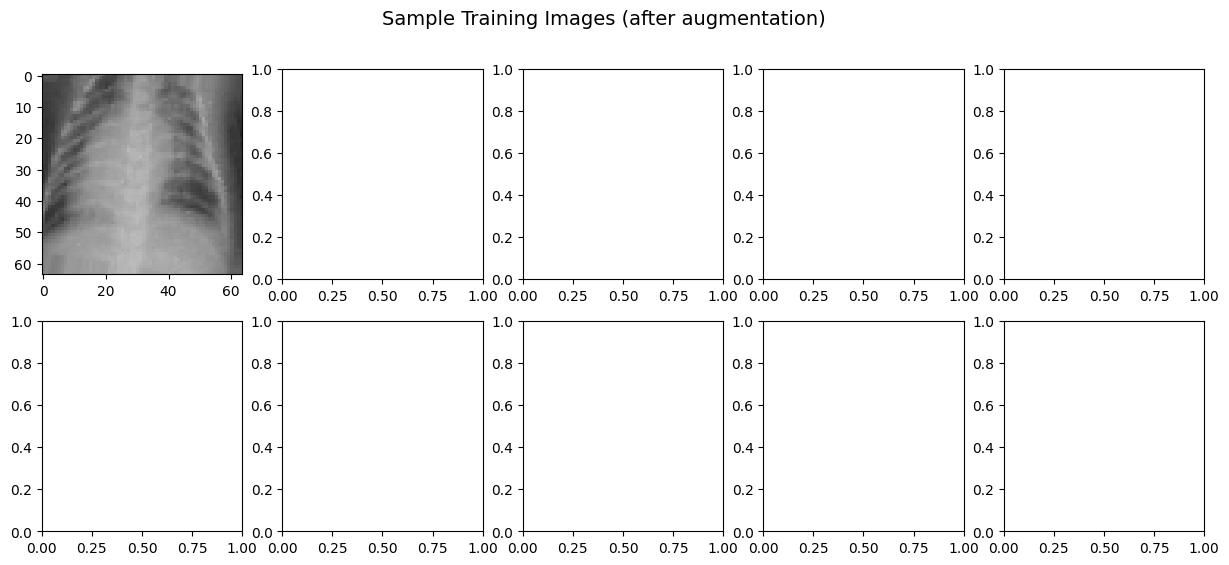

In [8]:
images, labels = next(train_data)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Training Images (after augmentation)", fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(CLASS_NAMES[int(labels[i])])
    ax.axis('off')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

## 6. Custom CNN Model

**Architecture overview:**
- 3 convolutional blocks, each with: `Conv2D → BatchNorm → MaxPool`
  - Filters double each block: 32 → 64 → 128 (learns increasingly abstract features)
- Flatten → Dense(256, ReLU) → BatchNorm → Dropout(0.5) → Dense(1, Sigmoid)
- Optimizer: Adam (lr=1e-4) | Loss: Binary Crossentropy
- **BatchNormalization** stabilizes training and accelerates convergence
- **Dropout(0.5)** prevents overfitting on the dense layer

> This is a custom baseline — no pretrained weights, trained from scratch.

In [9]:
# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.9445479962721341, 1: 0.6730645161290323}


In [ ]:
import tensorflow as tf

# Focal loss - designed specifically for class imbalance.
# alpha < 0.5 upweights the minority (NORMAL) class; gamma focuses training on hard examples.
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_weight = alpha_t * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.6),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),  # alpha=0.25 upweights NORMAL class
    metrics=['accuracy']
)

In [19]:
import os
SPLIT_VAL = "/Users/spathak/Downloads/chest_xray/split_data/val"
for cls in os.listdir(SPLIT_VAL):
    cls_path = os.path.join(SPLIT_VAL, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))} images")

PNEUMONIA: 775 images
NORMAL: 268 images


### 6.1 Train CNN

In [22]:
cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

cnn_history = cnn_model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=cnn_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nCNN training complete.")

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.8469 - loss: 0.0565
Epoch 1: val_accuracy improved from None to 0.74688, saving model to best_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 665ms/step - accuracy: 0.8476 - loss: 0.0572 - val_accuracy: 0.7469 - val_loss: 0.2091 - learning_rate: 1.0000e-04
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.8690 - loss: 0.0458
Epoch 2: val_accuracy improved from 0.74688 to 0.85810, saving model to best_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 91s 694ms/step - accuracy: 0.8670 - loss: 0.0490 - val_accuracy: 0.8581 - val_loss: 0.0699 - learning_rate: 1.0000e-04
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.8663 - loss: 0.0453
Epoch 3: val_accuracy improved from 0.85810 to 0.94631, saving model to best_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 641ms/step - accuracy: 0.8665 - loss: 0.0446 - val_accuracy: 0.9463 - val_loss: 0.0161 - learning_rate: 1.0000e-04
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_data.reset()
cnn_preds = (cnn_model.predict(test_data) > 0.5).astype(int)

print("CNN Test Results:")
print(classification_report(test_data.classes, cnn_preds, target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step
CNN Test Results:
              precision    recall  f1-score   support

      NORMAL       0.94      0.81      0.87       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



## 7. ResNet50 Transfer Learning

**Strategy — two-phase training:**

**Phase 1 (Feature extraction):** Freeze all ResNet50 layers. Only train the custom head. This lets the pretrained ImageNet weights act as a fixed feature extractor while the new head learns the task.

**Phase 2 (Fine-tuning):** Unfreeze the last 30 layers of ResNet50. Train with a very small learning rate (1e-5) so the pretrained weights are adjusted gradually without being destroyed.

> ResNet50 was pretrained on ImageNet (1.2M images, 1000 classes). Even though it hasn't seen X-rays, the low-level feature detectors (edges, textures, gradients) transfer well.

In [24]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    f"{DATASET_PATH}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = train_gen.flow_from_directory(
    f"{DATASET_PATH}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [27]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.9445479962721341, 1: 0.6730645161290323}


In [29]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks

# Load ResNet50 pretrained on ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze all base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

resnet_model = models.Model(inputs=base_model.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    callbacks.ModelCheckpoint('best_resnet.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

resnet_history = resnet_model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=resnet_callbacks,
    #class_weight=class_weight_dict,  # <-- add this
    verbose=1
)

print("\nResNet training complete.")

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7512 - loss: 0.5682
Epoch 1: val_accuracy improved from None to 0.83317, saving model to best_resnet.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 491s 4s/step - accuracy: 0.7884 - loss: 0.5189 - val_accuracy: 0.8332 - val_loss: 0.6501 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8482 - loss: 0.4281
Epoch 2: val_accuracy did not improve from 0.83317
131/131 ━━━━━━━━━━━━━━━━━━━━ 880s 7s/step - accuracy: 0.8486 - loss: 0.4182 - val_accuracy: 0.7709 - val_loss: 0.5290 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8622 - loss: 0.3803
Epoch 3: val_accuracy did not improve from 0.83317
131/131 ━━━━━━━━━━━━━━━━━━━━ 360s 3s/step - accuracy: 0.8747 - loss: 0.3670 - val_accuracy: 0.7891 - val_loss: 0.4354 - learning_rate: 1.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8962 - loss: 0.3209
Epoch 4: val_accuracy improved fr

In [30]:
test_data.reset()
resnet_preds = (resnet_model.predict(test_data) > 0.5).astype(int)

print("ResNet Test Results:")
print(classification_report(test_data.classes, resnet_preds, target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step
ResNet Test Results:
              precision    recall  f1-score   support

      NORMAL       0.94      0.50      0.66       234
   PNEUMONIA       0.77      0.98      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.74      0.76       624
weighted avg       0.83      0.80      0.79       624



## 8. Training Curves

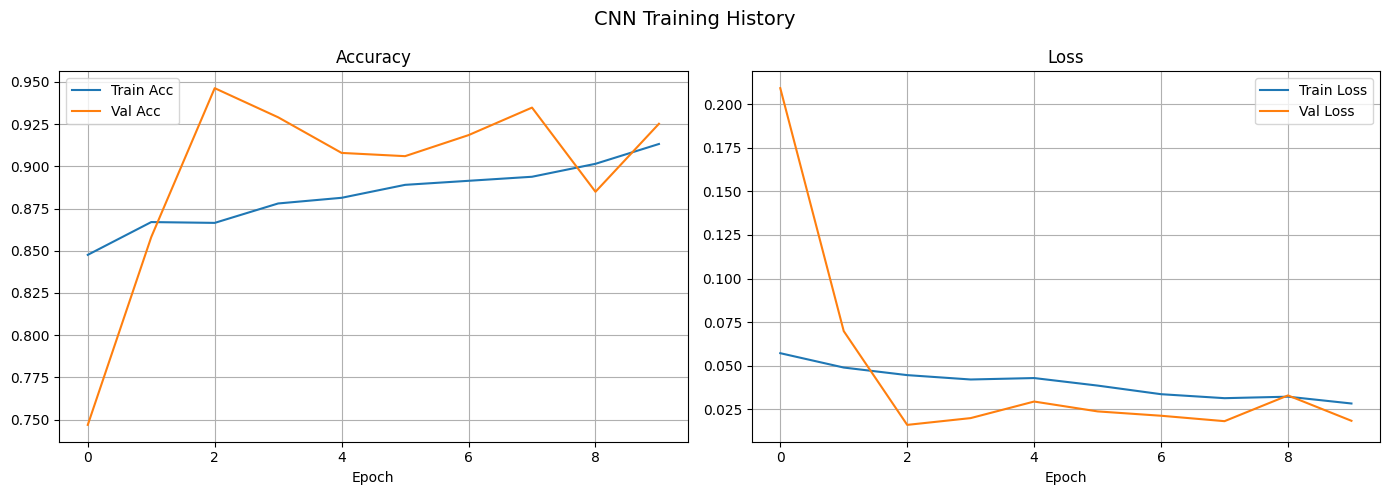

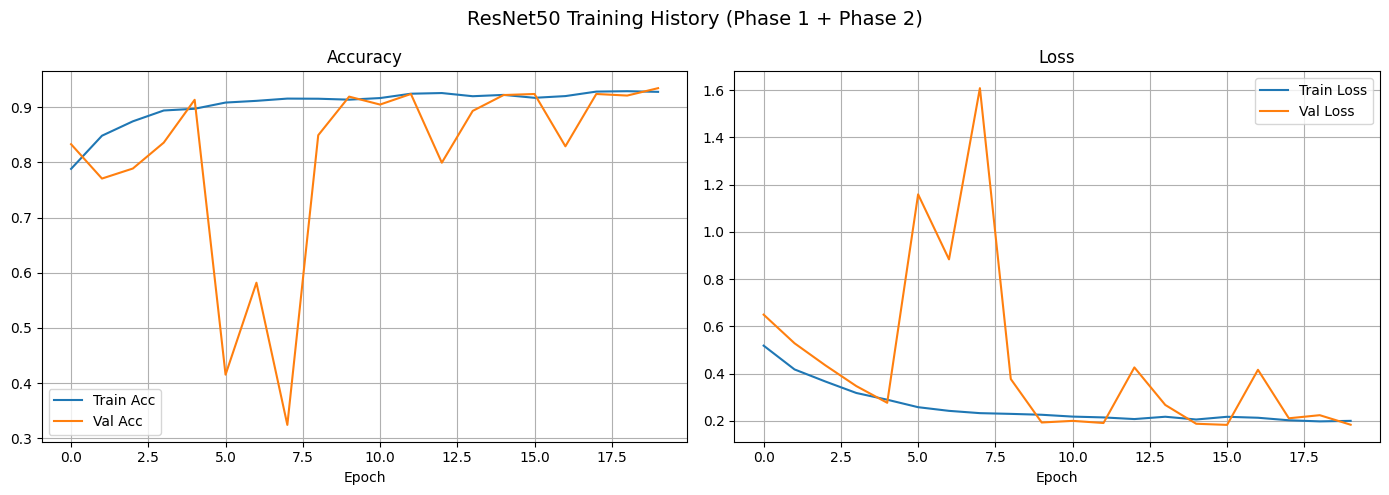

In [32]:
def plot_history(history, title, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14)

    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_history(cnn_history, "CNN Training History", "cnn_history.png")

# Combine Phase 1 + Phase 2 for ResNet
import collections
combined = collections.defaultdict(list)
for h in [resnet_history]:
    for k, v in h.history.items():
        combined[k].extend(v)

class FakeHistory:
    def __init__(self, d): self.history = d

plot_history(FakeHistory(combined), "ResNet50 Training History (Phase 1 + Phase 2)", "resnet_history.png")

In [35]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Reload both saved models
cnn_model = load_model('best_cnn.keras', 
                       custom_objects={'loss': tf.keras.losses.BinaryCrossentropy()})
resnet_model = load_model('best_resnet.keras')

print("Models loaded successfully")

# Verify input shapes
print("CNN input shape:", cnn_model.input_shape)
print("ResNet input shape:", resnet_model.input_shape)

Models loaded successfully
CNN input shape: (None, 64, 64, 3)
ResNet input shape: (None, 224, 224, 3)


## 9. Evaluation on Test Set

In [ ]:
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# Separate test generators for each model (CNN expects 64x64, ResNet50 expects 224x224)
test_gen_64 = ImageDataGenerator(rescale=1./255)
test_data_64 = test_gen_64.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_gen_224 = ImageDataGenerator(rescale=1./255)
test_data_224 = test_gen_224.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Evaluate both models
cnn_metrics    = evaluate_model(cnn_model,    test_data_64,  "CNN")
resnet_metrics = evaluate_model(resnet_model, test_data_224, "ResNet50")

# Final summary
better = "ResNet50" if resnet_metrics["f1"] > cnn_metrics["f1"] else "CNN"
print(f"""
{'='*60}
  FINAL ANALYSIS: CNN vs ResNet50
{'='*60}
           CNN       ResNet50
Accuracy   {cnn_metrics['accuracy']:.4f}    {resnet_metrics['accuracy']:.4f}
Precision  {cnn_metrics['precision']:.4f}    {resnet_metrics['precision']:.4f}
Recall     {cnn_metrics['recall']:.4f}    {resnet_metrics['recall']:.4f}
F1-Score   {cnn_metrics['f1']:.4f}    {resnet_metrics['f1']:.4f}

Winner: {better}
{'='*60}
""")

In [1]:
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# Separate test generators for each model
test_gen_64 = ImageDataGenerator(rescale=1./255)
test_data_64 = test_gen_64.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_gen_224 = ImageDataGenerator(rescale=1./255)
test_data_224 = test_gen_224.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Evaluate both models
cnn_metrics    = evaluate_model(cnn_model,    test_data_64,  "CNN")
resnet_metrics = evaluate_model(resnet_model, test_data_224, "ResNet50")


for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("comparison_bar_chart.png", dpi=150)
plt.show()

print("\n📊 Summary Table:")
print(f"{'Metric':<12} {'CNN':>10} {'ResNet50':>10} {'Winner':>10}")
print("-" * 45)
for name, cv, rv in zip(metrics_names, cnn_vals, resnet_vals):
    winner = "ResNet50" if rv > cv else ("CNN" if cv > rv else "Tie")
    print(f"{name:<12} {cv:>10.4f} {rv:>10.4f} {winner:>10}")


# Final summary
better = "ResNet50" if resnet_metrics["f1"] > cnn_metrics["f1"] else "CNN"
print(f"""
{'='*60}
  FINAL ANALYSIS: CNN vs ResNet50
{'='*60}
           CNN       ResNet50
Accuracy   {cnn_metrics['accuracy']:.4f}    {resnet_metrics['accuracy']:.4f}
Precision  {cnn_metrics['precision']:.4f}    {resnet_metrics['precision']:.4f}
Recall     {cnn_metrics['recall']:.4f}    {resnet_metrics['recall']:.4f}
F1-Score   {cnn_metrics['f1']:.4f}    {resnet_metrics['f1']:.4f}

Winner: {better}
{'='*60}
""")

NameError: name 'ImageDataGenerator' is not defined

## 10. Side-by-Side Comparison

In [34]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
cnn_vals    = [cnn_metrics["accuracy"],    cnn_metrics["precision"],    cnn_metrics["recall"],    cnn_metrics["f1"]]
resnet_vals = [resnet_metrics["accuracy"], resnet_metrics["precision"], resnet_metrics["recall"], resnet_metrics["f1"]]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, cnn_vals,    width, label='CNN',     color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, resnet_vals, width, label='ResNet50', color='darkorange', alpha=0.85)

ax.set_title("CNN vs ResNet50 — Test Set Performance", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("comparison_bar_chart.png", dpi=150)
plt.show()

print("\n📊 Summary Table:")
print(f"{'Metric':<12} {'CNN':>10} {'ResNet50':>10} {'Winner':>10}")
print("-" * 45)
for name, cv, rv in zip(metrics_names, cnn_vals, resnet_vals):
    winner = "ResNet50" if rv > cv else ("CNN" if cv > rv else "Tie")
    print(f"{name:<12} {cv:>10.4f} {rv:>10.4f} {winner:>10}")

NameError: name 'cnn_metrics' is not defined